In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [4]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [6]:
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [7]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [9]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [10]:
sentiment["date"] = pd.to_datetime(sentiment["timestamp"], unit="s")

In [11]:
sentiment["date"] = sentiment["date"].dt.date

In [12]:
trades["date"] = pd.to_datetime(trades["Timestamp"], unit="ms")

In [13]:
trades["date"] = trades["date"].dt.date

In [14]:
sentiment = sentiment[["date","classification","value"]]

In [15]:
merged = pd.merge(
    trades,
    sentiment,
    on="date",
    how="left"
)

In [16]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27,Greed,74.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27,Greed,74.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27,Greed,74.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27,Greed,74.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27,Greed,74.0


In [17]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
 16  date              21

In [18]:
merged.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [19]:
merged.drop_duplicates(inplace=True)

In [20]:
merged.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [21]:
merged = merged.dropna(subset=["classification"])

In [22]:
merged["classification"].value_counts()

,count
classification,
Fear,133871
Greed,36289
Neutral,7141
Extreme Greed,6962


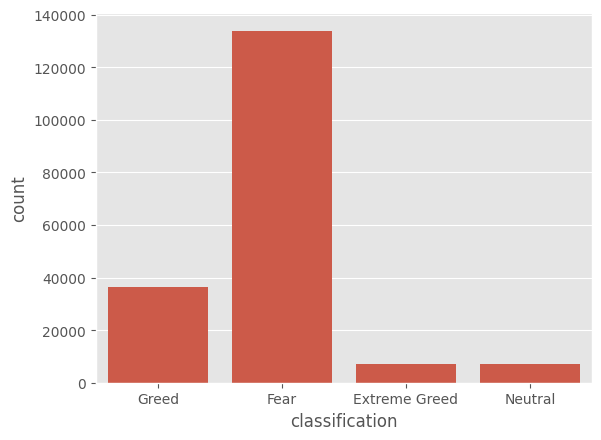

In [23]:
sns.countplot(data=merged,x="classification")
plt.show()

In [24]:
merged.groupby("classification")["Closed PnL"].mean()

,Closed PnL
classification,
Extreme Greed,25.418772
Fear,50.047622
Greed,87.894859
Neutral,22.229713


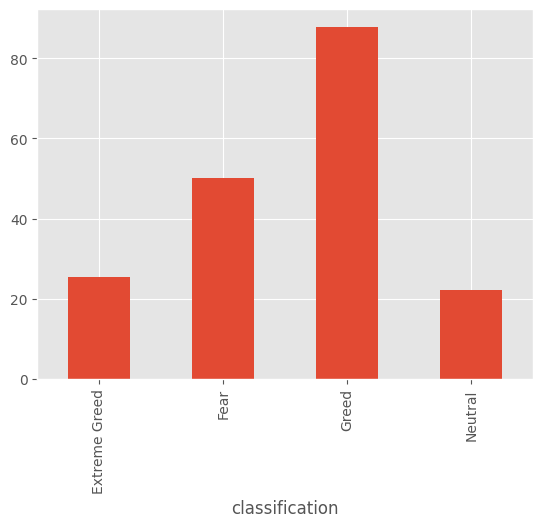

In [25]:
merged.groupby("classification")["Closed PnL"].mean().plot(kind="bar")
plt.show()

In [26]:
merged.groupby("classification")["Closed PnL"].sum()

,Closed PnL
classification,
Extreme Greed,1.769655e+05
Fear,6.699925e+06
Greed,3.189617e+06
Neutral,1.587424e+05


In [27]:
merged.groupby("classification")["Size USD"].mean()

,Size USD
classification,
Extreme Greed,5660.265764
Fear,5259.977837
Greed,3182.883845
Neutral,3058.848110


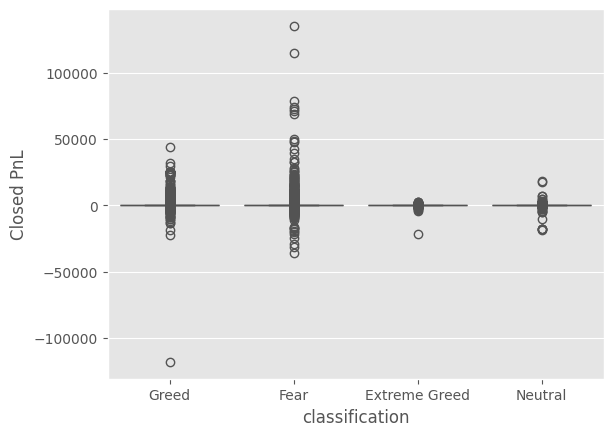

In [28]:
sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)
plt.show()

In [29]:
pd.crosstab(
    merged["classification"],
    merged["Side"]
)

Side,BUY,SELL
classification,,
Extreme Greed,3371,3591
Fear,66081,67790
Greed,15421,20868
Neutral,3505,3636


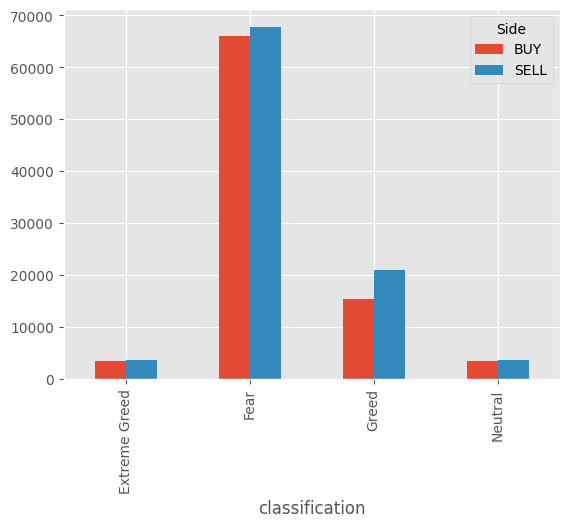

In [30]:
pd.crosstab(
    merged["classification"],
    merged["Side"]
).plot(kind="bar")
plt.show()

In [31]:
merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False)

,Closed PnL
Coin,
@107,2.776898e+06
HYPE,1.911331e+06
ETH,1.431097e+06
SOL,1.371096e+06
BTC,6.593113e+05
...,...
@135,-5.981364e+03
S,-8.644846e+03
IO,-2.189673e+04


In [32]:
merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

,Closed PnL
Coin,
@107,2.776898e+06
HYPE,1.911331e+06
ETH,1.431097e+06
SOL,1.371096e+06
BTC,6.593113e+05
MELANIA,3.168006e+05
ENA,2.173295e+05
SUI,1.986832e+05
ZRO,1.837778e+05


In [33]:
merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.040922e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401572e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.111830e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.744040e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.258152e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,4.035016e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0,3.936830e+05


In [34]:
merged.groupby("classification")["Fee"].mean()

,Fee
classification,
Extreme Greed,0.978567
Fear,1.083267
Greed,0.670562
Neutral,1.224461


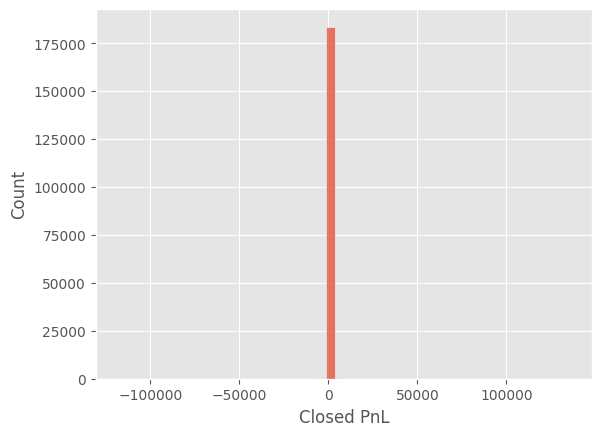

In [35]:
sns.histplot(
    merged["Closed PnL"],
    bins=50
)
plt.show()

In [36]:
numeric = merged.select_dtypes(include=np.number)

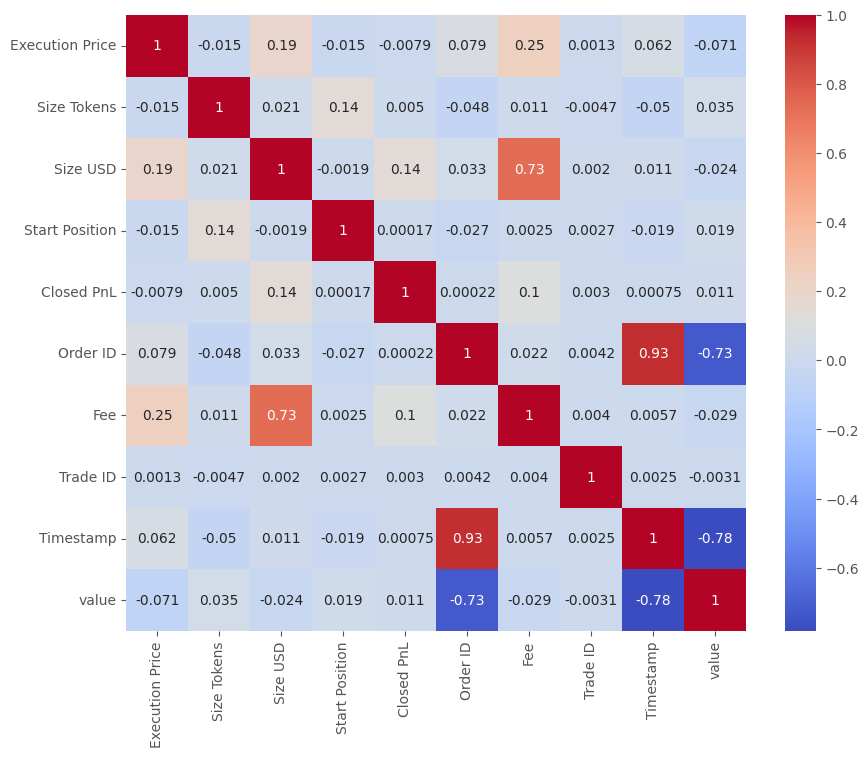

In [37]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [38]:
merged.sort_values(
    "Closed PnL",
    ascending=False
).head(10)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
18045,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,1570.10000,186.5296,292870.12,BUY,12-04-2025 12:31,-203.3554,Close Short,135329.09010,0x5dabcff879b7dd6b4fa7042162f3b00202d8003a722e...,85971520603,False,29.287012,1.090000e+15,1.740000e+12,2025-02-19,Fear,44.0
17270,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,2284.00000,300.0000,685200.00,BUY,28-02-2025 01:02,-1300.0000,Close Short,115287.00000,0x6c058403a14af5629152041e96740a02018800a5c347...,75527957029,False,68.520000,8.690000e+14,1.740000e+12,2025-02-19,Fear,44.0
18043,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,1570.10000,108.4516,170279.86,BUY,12-04-2025 12:31,-311.8148,Close Short,78682.72032,0xa71d6122ae6bc778a98d042162f36e0202c200228039...,85971520603,False,17.027985,5.760000e+12,1.740000e+12,2025-02-19,Fear,44.0
210024,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,ETH,3354.00000,274.7973,921670.14,BUY,08-01-2025 19:42,-274.7973,Close Short,74530.52371,0xcfae6d254e8f7ae06091041af73f1002010600c1234c...,61450313703,False,92.167014,9.190000e+14,1.740000e+12,2025-02-19,Fear,44.0
18024,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,1570.10000,99.7612,156635.06,BUY,12-04-2025 12:22,-417.5139,Close Short,72377.74821,0xd8d17e781bbe23cfd99c042162d89902013800a346fc...,85971520603,False,15.663506,3.680000e+14,1.740000e+12,2025-02-19,Fear,44.0
16328,0x083384f897ee0f19899168e3b1bec365f52a9012,SOL,210.88000,1431.4100,301855.74,BUY,04-02-2025 10:36,-5599.0800,Close Short,71535.71674,0x0e15abec26d8cb1a3a69041d1a0f9e02015d0095a16b...,69292154528,True,90.556722,9.360000e+14,1.740000e+12,2025-02-19,Fear,44.0
71354,0xbaaaf6571ab7d571043ff1e313a9609a10637864,HYPE,17.70400,63317.4200,1120971.60,SELL,05-03-2025 08:10,116541.6300,Close Long,68959.00212,0x0391d319e62be49373f4041eed87270208ee00705347...,77255189086,True,280.242900,9.170000e+14,1.740000e+12,2025-02-19,Fear,44.0
16377,0x083384f897ee0f19899168e3b1bec365f52a9012,SOL,202.69000,866.1300,175555.89,BUY,04-02-2025 11:15,-1689.3800,Close Short,50379.05774,0xd07c1ad82c5aa246e23e041d1a7c8a02016b00a8dd84...,69309451930,False,8.777794,4.660000e+14,1.740000e+12,2025-02-19,Fear,44.0
49084,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,DOGE,0.25415,236789.0000,60179.92,BUY,09-02-2025 21:56,-286801.0000,Close Short,48504.09555,0x07b7cdc7e66e9ea98dcb041d726c1701b600104ad57c...,70984912926,True,21.062973,9.990000e+14,1.740000e+12,2025-02-19,Fear,44.0
17075,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,2541.70000,309.1061,785654.97,BUY,25-02-2025 03:40,-1504.5823,Close Short,47883.62595,0x97d51ad99f2a1c25b084041e66a1da020241003aae4b...,74570997098,True,274.979241,9.100000e+13,1.740000e+12,2025-02-19,Fear,44.0


In [39]:
merged.sort_values(
    "Closed PnL"
).head(10)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
14682,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,4041.000,201.5650,814524.17,BUY,06-12-2024 23:15,-559.283400,Close Short,-117990.10410,0x708d15cf3ed40382ad00041894851a0203b8006ff533...,53292414040,False,81.452416,1.060000e+15,1.730000e+12,2024-10-27,Greed,74.0
210767,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,SOL,133.600,1777.9800,237538.13,BUY,18-04-2025 20:03,-1777.980000,Close Short,-35681.74723,0x77cd8bc91ee6e2f1429c0421c9a82a02077d0041becd...,87333347541,False,23.753812,4.030000e+14,1.740000e+12,2025-02-19,Fear,44.0
142241,0x39cef799f8b69da1995852eea189df24eb5cae3c,@107,13.600,5900.9400,80252.78,SELL,10-03-2025 23:27,5900.947911,Sell,-31036.69194,0x93e3a73f9d3f5496edab041f4a7dc80201a1000d006b...,78769451934,False,8.025278,1.090000e+15,1.740000e+12,2025-02-19,Fear,44.0
3737,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,81403.000,4.5860,373314.16,BUY,09-04-2025 23:02,-7.797140,Close Short,-29370.11980,0x6a6b29312318fc5169a404213909ee020342000241b6...,85369144282,False,35.838158,1.100000e+15,1.740000e+12,2025-02-19,Fear,44.0
203858,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,BERA,10.750,10000.0000,107500.00,SELL,06-02-2025 20:34,10000.000000,Close Long,-24500.00000,0xae8a0cefc7a10e977bfd041d411955020334004fa7af...,70158958316,False,10.750000,4.960000e+14,1.740000e+12,2025-02-19,Fear,44.0
164243,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,@107,26.395,5777.9200,152508.20,SELL,23-12-2024 11:43,20895.254140,Sell,-22634.46345,0x7c1bdc9a1aaec8d338230419d811750201b60057cd10...,57957457746,True,45.752459,5.790000e+14,1.730000e+12,2024-10-27,Greed,74.0
21604,0x4f93fead39b70a1824f981a54d4e55b278e9f760,ETH,2970.000,60.0000,178200.00,SELL,14-04-2024 01:37,88.820000,Close Long,-21524.40000,0x13d61ce666aa5598cd38040877138202010300c4a2a4...,17953732002,True,62.370000,7.880000e+14,1.710000e+12,2024-03-09,Extreme Greed,84.0
3546,0x513b8629fe877bb581bf244e326a047b249c4ff1,HYPE,10.497,9261.7300,97220.38,SELL,07-04-2025 00:37,22673.420000,Close Long,-21333.46888,0xdf46c6ed154d0dbcebc1042108919b02013f00e09dfd...,84309098169,False,9.333155,5.170000e+14,1.740000e+12,2025-02-19,Fear,44.0
15760,0x083384f897ee0f19899168e3b1bec365f52a9012,ETH,2535.000,156.5878,396950.07,SELL,03-02-2025 08:48,1252.260500,Close Long,-19841.24014,0x9470144093d6e8196819041d089a0202026100037040...,68791113611,False,19.847503,4.750000e+14,1.740000e+12,2025-02-19,Fear,44.0
25299,0x4f93fead39b70a1824f981a54d4e55b278e9f760,BTC,91627.000,2.8233,258690.51,SELL,10-01-2025 02:04,3.763070,Close Long,-18993.46842,0xa5a246e7b3b00b383fba041b11831202019800ce99b6...,61875044905,True,90.541678,9.880000e+14,1.740000e+12,2025-02-19,Fear,44.0
